<a href="https://colab.research.google.com/github/mvarentsov/ML4hydromet-2025/blob/main/examples/Lect09_LSTM_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Импорты
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

In [2]:
# ГИПЕРПАРАМЕТРЫ И КОНСТАНТЫ
RANDOM_SEED = 43  # фиксированное число рандома
SEQ_LENGTH = 3  # длина последовательности
HIDDEN_SIZE = 64 # Размерность вектора каждого входа модели
NUM_LAYERS = 3 # количество слоев нейросети
N_SPLITS = 5  # количество блоков для кросс-валидации
NUM_EPOCHS = 16  # количество эпох обучения
BATCH_SIZE = 64  # размер батча
LEARNING_RATE = 0.001  # ленинг рейт)

In [3]:
# задаем фиксированные рандомы
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [4]:
# Загрузка данных
#df = pd.read_csv('D:/RSHU_LIMA_VARENTSOV_2025/data/Moscow_basic.csv', sep=';')
df = pd.read_csv("Moscow_basic.csv", sep=';')
df = df.drop(['time', 'delta_t2m_id27416', 'delta_t2m_id27612', 'delta_t2m_id27617'], axis=1)

columns_to_drop = [col for col in df.columns if col.startswith('rur')]     # оставляем данные реанализа
df = df.drop(columns_to_drop, axis=1)

df = df.dropna()      # удаляем пропуски

df_test = df.iloc[27511:27752] # июнь 2021 г
#print(df_test)
df_test = df_test.sort_index()  # Убедимся в хронологическом порядке
#print(df_test.head())

df_main = df.drop(df.index[27511:27752]) # остальной набор данных
#print(df_main)
df_main = df_main.sort_index()  # Убедимся в хронологическом порядке
#print(df_main.head())

In [6]:
# Тренировочный/тестовый набор

def create_seq (df, features, target, seq_len):
    n = len(df)
    indices = np.arange(seq_len) + np.arange(0, n - seq_len + 1)[:, None]  # Shape: (n_seq, seq_len)

    X_data = df[features].values.astype(np.float32)
    y_data = df[target].values.astype(np.float32)

    X_seq = X_data[indices]  # Shape: (n_sequences, seq_len, n_features)
    y_seq = y_data[seq_len - 1:]  # First target at index SEQ_LENGTH - 1

    return X_seq, y_seq



train_data = df_main.copy()
test_data = df_test.copy()

# Выделение признаков и целевой переменной
features = train_data.columns.drop('delta_t2m_id27605')
target = 'delta_t2m_id27605'

X_train, y_train = create_seq(train_data, features, target, SEQ_LENGTH)
X_test, y_test = create_seq(test_data, features, target, SEQ_LENGTH)


In [7]:

"""
Подробно разберем пример с разделением на последовательности:
Пусть SEQ_LENGTH = 3 и у нас блок с 10 точками:

Индексы:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Данные:   [A, B, C, D, E, F, G, H, I, J]

Цикл начинается с i = 2 (SEQ_LENGTH - 1):

Итерация 1 (i = 2):
X_block[2-3+1:2+1] = X_block[0:3] = [A, B, C]
y_block[2] = C

Логика: Используем точки [0,1,2] чтобы предсказать точку 2

Итерация 2 (i = 3):
X_block[3-3+1:3+1] = X_block[1:4] = [B, C, D]
y_block[3] = D

Логика: Используем точки [1,2,3] чтобы предсказать точку 3

Итерация 3 (i = 4):
X_block[4-3+1:4+1] = X_block[2:5] = [C, D, E]
y_block[4] = E
И так далее...

Последняя итерация (i = 9):
X_block[9-3+1:9+1] = X_block[7:10] = [H, I, J]
y_block[9] = J
"""

# Определение модели LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.regressor(out[:, -1, :]).squeeze()

# Нормализация данных
scaler_X = StandardScaler().fit(X_train.reshape(-1, X_train.shape[2]))
scaler_y = StandardScaler().fit(y_train.reshape(-1, 1))

X_train_scaled = scaler_X.transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)
y_train_scaled = scaler_y.transform(y_train.reshape(-1, 1)).flatten()

# Создание DataLoader
train_dataset = TensorDataset(torch.tensor(X_train_scaled), torch.tensor(y_train_scaled))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Обучение модели
model = LSTMModel(input_size=X_train.shape[2])
print (model)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in tqdm (range(NUM_EPOCHS)):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = torch.sqrt(nn.MSELoss()(outputs, batch_y))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

# Предсказание на тестовых данных
model.eval()
with torch.no_grad():
    test_preds_scaled = model(torch.tensor(X_test_scaled)).numpy()

# Обратное преобразование нормализации
y_pred_LSTM = scaler_y.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()

# Вычисление метрик
rmse = np.sqrt(mean_squared_error(y_test, y_pred_LSTM))
r2 = r2_score(y_test, y_pred_LSTM)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

# Создание полного временного ряда моделирования
full_predictions = np.empty(len(test_data))
full_predictions[:] = np.nan  # Заполняем все значения NaN

# Записываем предсказания начиная с индекса SEQ_LENGTH-1
full_predictions[SEQ_LENGTH-1:] = y_pred_LSTM

# Сохранение предсказаний с правильным выравниванием по времени
predictions = pd.DataFrame({
    'true': test_data[target].values,
    'predicted': full_predictions
})

LSTMModel(
  (lstm): LSTM(15, 64, num_layers=3, batch_first=True)
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


100%|██████████| 16/16 [01:04<00:00,  4.04s/it]

Test RMSE: 1.0344
Test R²: 0.7926


<Axes: >

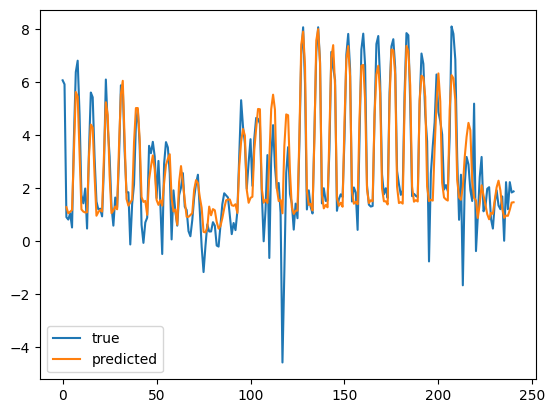

In [8]:
predictions.plot()